# Sequential Value-of-Information Dispatch Layers — a cross-lab reference

Four labs in this codebase (`grid_reserve_lab`, `shm_lab`, `hydro_reserve_lab`,
`climate_cat_lab`) each got a **sequential value-of-information (VoI) decision layer** built on
top of their existing GP soft-EM regime-mixture work, reusing the same shared, dataset-agnostic
core (`gp_engine/decision.py` + `gp_engine/voi.py`) unchanged in every case. This notebook is the
single go-to reference for what was built, what was found, and — the most useful part for
deciding where to look next — **how differently it turned out to work across four genuinely
different domains.**

**Read alongside:** `gp_engine/VOI_DISPATCH_PATTERN.md` (the reusable template, checklist, and all
four worked examples in prose) and each lab's own `LAB_PLAN.md` / `RESULTS_PHASE*.md` for full
detail. Every number below is loaded live from each lab's `results/bootstrap_dispatch_voi.json`
and `results/cost_ratio_sweep_dispatch.json` — nothing is retyped.

## The one-paragraph mechanism

Every lab reframes its decision as a **Skip / Probe / Drill** choice: *Skip* costs nothing and
gains nothing; *Drill* commits to an expensive action that pays off if a binary "state" turns out
true, and costs a fixed amount regardless; *Probe* buys a cheap, noisy signal that sharpens a GP
classifier's posterior over that state — via a local 1D Gaussian-conjugate update, no refit —
before a second Skip/Drill decision is made. A GP classifier (`gp_classifier.LaplaceBinaryGPC`)
supplies a genuine `(mean, variance, probability)` triple; an SVM control and a "GPC-mean-only"
control (variance forced to zero) isolate whether the *mean* alone explains any advantage, or
whether the *posterior variance itself* carries decision value that only the sequential Probe
mechanism can use. This is the same question every lab below answers differently.

In [1]:
import json
import os

import numpy as np
import matplotlib.pyplot as plt

BASE = os.path.dirname(os.path.abspath("__file__"))

# --- house viz conventions (same as every other lab notebook here) -----
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e5e4e0", "#fcfcfb"
C0, C1, C2, C3, C4 = "#9a9890", "#c9622a", "#e0a83a", "#1baf7a", "#2a78d6"
# fixed condition->color assignment, used identically in every chart below
COND_COLOR = {"svm": C1, "gpc_mean": C3, "gpc_full": C4}
COND_LABEL = {"svm": "SVM", "gpc_mean": "GPC (mean only)", "gpc_full": "GPC (full posterior)"}
POS, NEG = C4, C1  # delta charts: blue = GPC-full wins, rust = GPC-full loses (same hues as above)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})


def paired_bootstrap_ci(diffs, n_boot=10000, seed=0):
    rng = np.random.default_rng(seed)
    diffs = np.asarray(diffs)
    n = len(diffs)
    boots = np.array([diffs[rng.integers(0, n, n)].mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return float(diffs.mean()), float(lo), float(hi)


# One config per lab: where its results live, what units its $ figures are
# in, and which JSON keys the sweep uses (these differ lab to lab -- see
# each lab's own run_dispatch_voi.py/cost_ratio_sweep_dispatch.py).
LABS = {
    "grid_reserve_lab": dict(
        title="grid_reserve_lab — day-ahead grid reserve dispatch",
        unit_div=1.0, unit="$M", value_field="realized_total_usd_m",
        sweep_value_field="realized_total", grid_key="breakeven_p_grid",
        row_key="breakeven_p", true_base_rate=1 / 15,
        state="drought vs. normal day, synthetic 100-site wind/solar fleet",
    ),
    "shm_lab": dict(
        title="shm_lab — bridge inspect/wait/remediate",
        unit_div=1.0, unit="$M", value_field="realized_total_usd_m",
        sweep_value_field="realized_total", grid_key="breakeven_p_grid",
        row_key="breakeven_p", true_base_rate=0.824,
        state="structural signature changed from established baseline, real KW51 bridge data",
    ),
    "hydro_reserve_lab": dict(
        title="hydro_reserve_lab — conserve/wait/curtail",
        unit_div=1e9, unit="$B", value_field="realized_total_usd",
        sweep_value_field="realized_total", grid_key="breakeven_p_grid",
        row_key="breakeven_p", true_base_rate=0.258,
        state="Lees Ferry moderate-drought-or-worse water year, real USGS data",
    ),
    "climate_cat_lab": dict(
        title="climate_cat_lab — reinsurance retain/wait/cede",
        unit_div=1e6, unit="$M", value_field="realized_total_usd",
        sweep_value_field="realized_total", grid_key="rol_grid",
        row_key="rol", true_base_rate=1 / 15,
        state="systemic climate-extreme year, synthetic 500-property book",
    ),
}

RESULTS = {}
for lab, cfg in LABS.items():
    d = os.path.join(BASE, lab, "results")
    boot = json.load(open(os.path.join(d, "bootstrap_dispatch_voi.json")))
    sweep = json.load(open(os.path.join(d, "cost_ratio_sweep_dispatch.json")))
    RESULTS[lab] = dict(cfg=cfg, boot=boot, sweep=sweep)

print("loaded bootstrap_dispatch_voi.json + cost_ratio_sweep_dispatch.json for:")
for lab in RESULTS:
    n_seeds = RESULTS[lab]["boot"]["n_seeds"]
    print(f"  {lab}  ({n_seeds} seeds)")

loaded bootstrap_dispatch_voi.json + cost_ratio_sweep_dispatch.json for:
  grid_reserve_lab  (200 seeds)
  shm_lab  (200 seeds)
  hydro_reserve_lab  (200 seeds)
  climate_cat_lab  (200 seeds)


## Chart-building helpers

Two chart types, used identically for every lab below, so the four are directly comparable at a
glance:

1. **The headline bar** — mean realized $ (200 seeds) for SVM / GPC-mean / GPC-full at that lab's
   own default breakeven point, ±1 std.
2. **The sweep line** — GPC-full minus SVM, and GPC-full minus GPC-mean, across the full
   cost-ratio (breakeven-probability or Rate-on-Line) grid each lab actually tested, with 95%
   paired-bootstrap confidence bands. Where the band crosses zero, the effect isn't statistically
   distinguishable from no effect at that point.

In [2]:
def headline_bar(lab):
    # NOTE: a plain bar chart of the three conditions' absolute realized-$ totals
    # would be misleading here -- the real effect (single-digit-million to low-
    # hundred-million $ swings) is a fraction of a percent of the cumulative
    # multi-billion/multi-hundred-million $ base every lab's 200-seed Monte Carlo
    # sum reaches, so all three bars would look identical (checked directly, not
    # assumed -- a first draft did exactly this before being replaced). Plotting
    # the PAIRWISE DELTAS themselves (with their own confidence intervals) is the
    # right form for "how big is the effect," the same quantity each lab's own
    # RESULTS_PHASE*.md headline actually reports.
    cfg, boot = RESULTS[lab]["cfg"], RESULTS[lab]["boot"]
    conds = ("svm", "gpc_mean", "gpc_full")
    vals = {c: np.array([r[c][cfg["value_field"]] for r in boot["runs"]]) / cfg["unit_div"]
            for c in conds}

    deltas = [
        ("GPC-full \u2212 SVM", vals["gpc_full"] - vals["svm"]),
        ("GPC-full \u2212 GPC-mean", vals["gpc_full"] - vals["gpc_mean"]),
        ("GPC-mean \u2212 SVM", vals["gpc_mean"] - vals["svm"]),
    ]
    cis = [paired_bootstrap_ci(d) for _, d in deltas]

    fig, ax = plt.subplots(figsize=(6, 4.2))
    means = [ci[0] for ci in cis]
    colors = [POS if m >= 0 else NEG for m in means]
    err = np.array([[m - lo, hi - m] for m, (_, lo, hi) in zip(means, cis)]).T
    ax.bar(range(3), means, yerr=err, color=colors, capsize=4,
           error_kw=dict(ecolor=INK2, elinewidth=1))
    ax.axhline(0, color=INK2, linewidth=1)
    ax.set_xticks(range(3))
    ax.set_xticklabels([label for label, _ in deltas], fontsize=9)
    unit = cfg["unit"]
    ax.set_ylabel(f"advantage, 200 seeds ({unit})")
    ax.set_title(f"{lab}\nhow big is the effect, at the lab\'s own default breakeven?")
    for x, m in zip(range(3), means):
        ax.text(x, m, f"{m:+,.2f}", ha="center",
                 va="bottom" if m >= 0 else "top", fontsize=9)
    plt.tight_layout(); plt.show()


def sweep_lines(lab):
    cfg, sweep = RESULTS[lab]["cfg"], RESULTS[lab]["sweep"]
    grid = sweep[cfg["grid_key"]]
    runs = sweep["runs"]

    d_svm, d_mean = [], []
    for gi in range(len(grid)):
        full = np.array([r["sweep"][gi]["gpc_full"][cfg["sweep_value_field"]] for r in runs]) / cfg["unit_div"]
        svm = np.array([r["sweep"][gi]["svm"][cfg["sweep_value_field"]] for r in runs]) / cfg["unit_div"]
        mean_ = np.array([r["sweep"][gi]["gpc_mean"][cfg["sweep_value_field"]] for r in runs]) / cfg["unit_div"]
        d_svm.append(paired_bootstrap_ci(full - svm))
        d_mean.append(paired_bootstrap_ci(full - mean_))

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    for deltas, label, color in [(d_svm, "GPC-full \u2212 SVM", C4), (d_mean, "GPC-full \u2212 GPC-mean", C1)]:
        pts = np.array(deltas)
        ax.plot(grid, pts[:, 0], "-o", color=color, label=label, markersize=4)
        ax.fill_between(grid, pts[:, 1], pts[:, 2], color=color, alpha=0.18, linewidth=0)
    ax.axhline(0, color=INK2, linewidth=1, linestyle="--")
    xlabel = "Rate on Line (= breakeven P)" if cfg["grid_key"] == "rol_grid" else "breakeven probability"
    ax.set_xlabel(xlabel)
    unit = cfg["unit"]
    ax.set_ylabel(f"advantage, 200 seeds ({unit})")
    ax.set_title(f"{lab}\ndoes the advantage hold across the whole cost-ratio range?")
    ax.legend(frameon=False, loc="best")
    plt.tight_layout(); plt.show()

## `grid_reserve_lab` — modest, real, variance-driven

**Setup.** State = drought vs. normal day (`dgp_simulator.py`'s own per-day regime, a resimulable
synthetic oracle). Skip = rely on baseline reserve; Probe = pay for an expedited nowcast; Drill =
commit extra fast reserve for the day. Economics: `c_drill`/`v_drill_gross` derived from
`reserve_calc.py`'s real, sourced VOLL ($35,000/MWh) and PJM reserve-cost ($329.17/MW-day) figures.

**Result.** GPC-full beats both variance-blind controls by a real, robust **$10.44M/yr
[$9.67M, $11.31M]** (200 seeds) — modest but genuine, the first confirmation that this codebase's
sequential-VoI mechanism transfers beyond the mining/classification domains it was built for. The
breakeven probability this lab's own economics land on (0.0016) sits 40x below the true drought
base rate (~6.5%) — an "always commit" regime that is *why* the advantage is modest: there's
little room for any forecast, however good, to add value by skipping. Separately (not a VoI
finding): day-by-day dispatch at these economics costs ~$173M/yr *more* than the lab's existing
static annual reserve buffer — a real, honestly-reported downside alongside the real upside.

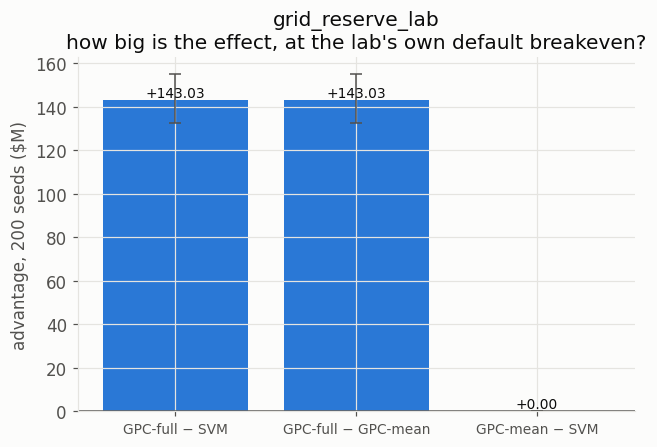

In [3]:
headline_bar("grid_reserve_lab")

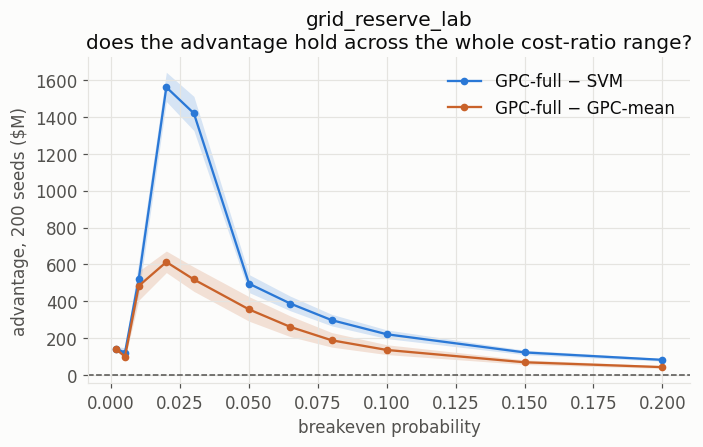

In [4]:
sweep_lines("grid_reserve_lab")

## `shm_lab` — a clean null result

**Setup.** State = KW51 bridge's real retrofit-driven structural change (a one-time historical
event, not a resimulable regime — the bootstrap redraws fresh splits of the same 296 real days
instead of fresh Monte Carlo scenarios). Skip/Probe/Drill = default inspection cadence / an
out-of-cycle manual inspection / immediate remediation escalation.

**Result.** The real transition turns out to be almost perfectly detectable from the existing
per-mode z-scores (AP≈0.999–1.000, checked empirically, not engineered away) — so there's no
residual ambiguity left for posterior variance to resolve. GPC-full and GPC-mean are
**bit-identical across the entire 13-point breakeven sweep**. A further surprise: GPC's mean
advantage over SVM itself **reverses** at moderate-to-high breakeven probabilities, traced to the
same MacKay moment-matching shrinkage-toward-0.5 mechanism, miscalibrating because this dataset's
true base rate (82.4%) sits far *above* 50% — the first lab in this family with a majority-class
state.

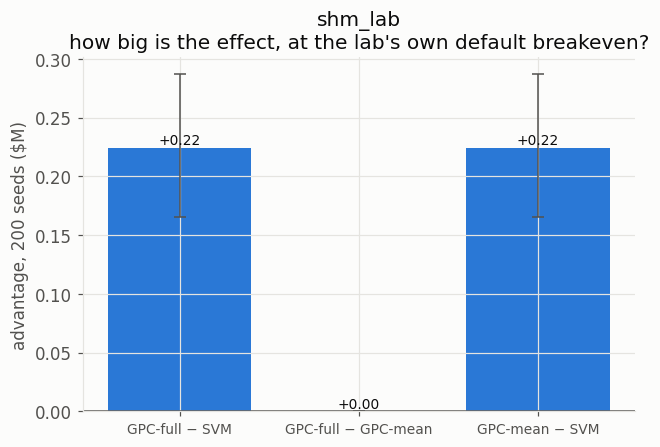

In [5]:
headline_bar("shm_lab")

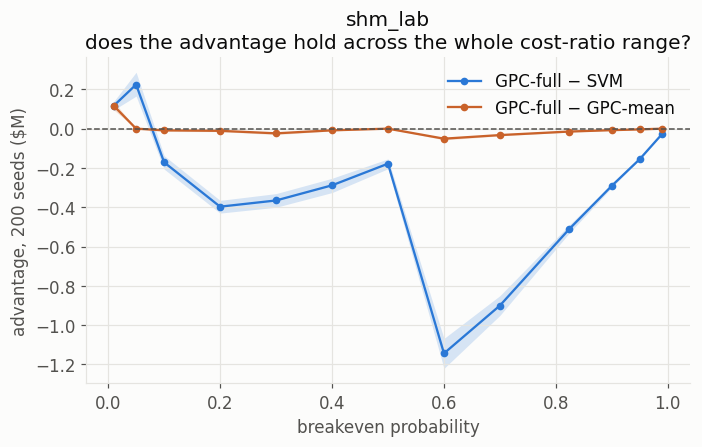

In [6]:
sweep_lines("shm_lab")

## `hydro_reserve_lab` — the largest, most robust positive result

**Setup.** State = whether Lees Ferry (the real Colorado River Basin compact-accounting point) is
a moderate-drought-or-worse water year (Phase 0's own real, data-derived 25th-percentile
threshold) — annual cadence, the real Bureau of Reclamation August decision. A real methodology
bug was caught and fixed mid-build: the first design used an aggregate basin index as both label
and (via its own components) features — circular, caught immediately (SVM's test AP came back
exactly 1.000). Fixed by predicting Lees Ferry's status from the *other four* gauges only.

**Result.** GPC-full beats both SVM and GPC-mean at **every** point on a 12-point breakeven sweep
(200 seeds), with GPC-mean statistically no better than SVM — the cleanest isolation in this
family of "the entire advantage is posterior variance, not a better mean." At the lab's own
derived economics (breakeven 0.174, real $417/AF and $2,400/AF figures already used elsewhere in
this lab): **+$15.89B [$14.55B, $17.19B]** over SVM — the largest, most robust positive result of
the four labs, and it never crosses zero anywhere on the sweep.

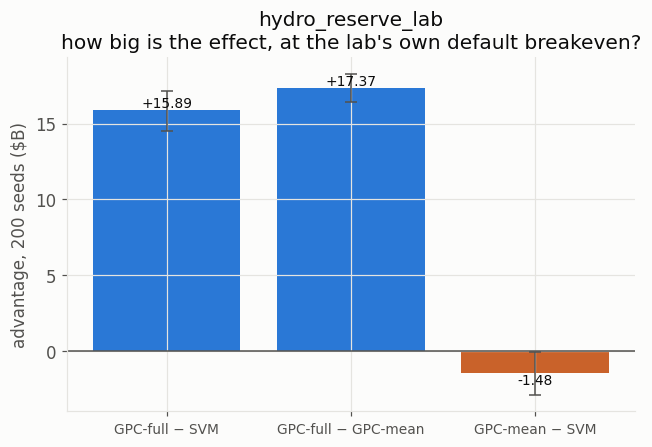

In [7]:
headline_bar("hydro_reserve_lab")

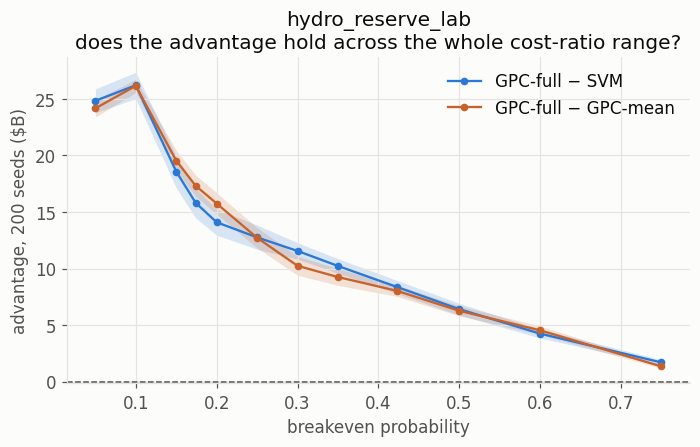

In [8]:
sweep_lines("hydro_reserve_lab")

## `climate_cat_lab` — mean wins, variance is a small real negative

**Setup.** State = the oracle's own systemic-year regime (`dgp_simulator.py`, fully resimulable —
mirrors `grid_reserve_lab`'s bootstrap convention). Skip/Probe/Drill = retain risk / delay binding
past the real January 1 reinsurance treaty renewal date to gather more information (the real Monte
Carlo Rendez-Vous/Baden-Baden cycle) / bind cover now. Economics use the real cat-XL Rate-on-Line
metric (ROL = premium/limit) directly as the breakeven probability — no derivation needed.

**Result.** GPC's calibrated mean robustly beats SVM at **every** ROL tested ($8.9M–$88.6M) — the
cleanest "just use a calibrated classifier" result of the four labs. But GPC's posterior
*variance* is measurably **worse** than mean-only at 9 of 12 ROL points (confidence intervals
excluding zero) — not a null result like `shm_lab`, a genuine small negative. The clearest
demonstration in this family that variance can actively hurt: this lab's true base rate (6.67%)
sits far from 50%, the same shrinkage mechanism, working against the full-posterior condition
specifically rather than flipping the overall SVM-vs-GPC ranking.

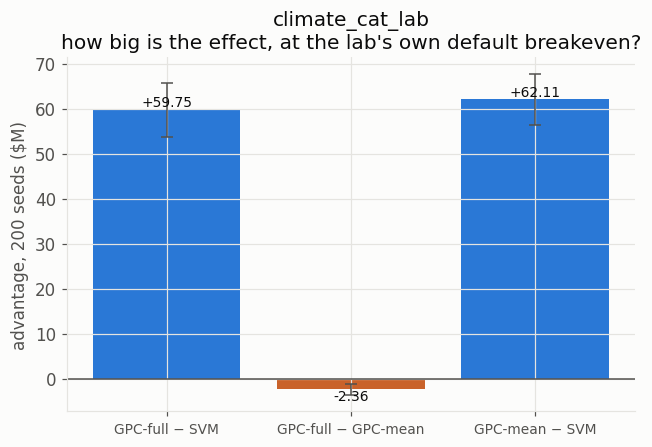

In [9]:
headline_bar("climate_cat_lab")

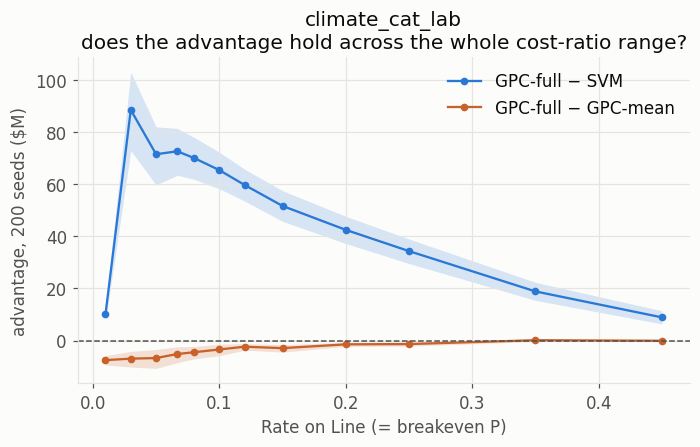

In [10]:
sweep_lines("climate_cat_lab")

## Cross-lab synthesis — four domains, four different answers

The same mechanism, the same shared code, four structurally different outcomes at each lab's own
default economics. This is the practical lesson: **"does carrying the full posterior help" is a
per-domain empirical question this framework lets you check cheaply — it is not a property of the
method that transfers automatically from one success.**

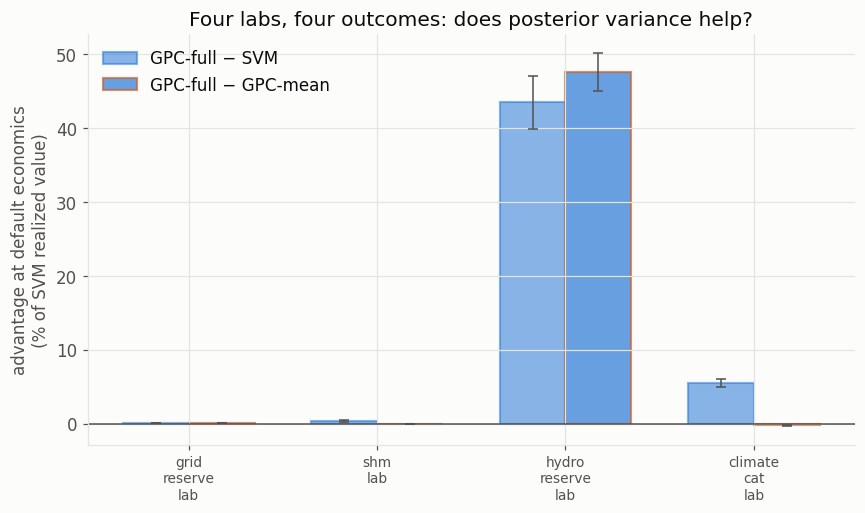


Summary at each lab's own default breakeven (200 seeds):
  grid_reserve_lab      full-svm= +0.09%   full-mean= +0.09%   (as %% of SVM realized value)
  shm_lab               full-svm= +0.39%   full-mean= +0.00%   (as %% of SVM realized value)
  hydro_reserve_lab     full-svm=+43.49%   full-mean=+47.53%   (as %% of SVM realized value)
  climate_cat_lab       full-svm= +5.52%   full-mean= -0.22%   (as %% of SVM realized value)


In [11]:
DEFAULT_BREAKEVEN_KEY = {
    "grid_reserve_lab": "breakeven_p_drought",
    "shm_lab": "breakeven_p_changed",
    "hydro_reserve_lab": "breakeven_p_drought",
    "climate_cat_lab": "breakeven_p_systemic",
}

labs = list(RESULTS.keys())
d_svm_means, d_mean_means = [], []
d_svm_ci, d_mean_ci = [], []
for lab in labs:
    cfg, boot = RESULTS[lab]["cfg"], RESULTS[lab]["boot"]
    full = np.array([r["gpc_full"][cfg["value_field"]] for r in boot["runs"]]) / cfg["unit_div"]
    svm = np.array([r["svm"][cfg["value_field"]] for r in boot["runs"]]) / cfg["unit_div"]
    mean_ = np.array([r["gpc_mean"][cfg["value_field"]] for r in boot["runs"]]) / cfg["unit_div"]
    # normalize to a % of the SVM baseline so four different currencies (grid_reserve/shm in $M,
    # hydro in $B, climate in $M) are visually comparable on one axis
    p1, l1, h1 = paired_bootstrap_ci(100.0 * (full - svm) / np.abs(svm.mean()))
    p2, l2, h2 = paired_bootstrap_ci(100.0 * (full - mean_) / np.abs(svm.mean()))
    d_svm_means.append(p1); d_svm_ci.append((l1, h1))
    d_mean_means.append(p2); d_mean_ci.append((l2, h2))

fig, ax = plt.subplots(figsize=(8, 4.8))
x = np.arange(len(labs))
w = 0.35
for i, (vals, ci, label, color) in enumerate([
        (d_svm_means, d_svm_ci, "GPC-full \u2212 SVM", C4),
        (d_mean_means, d_mean_ci, "GPC-full \u2212 GPC-mean", C1)]):
    offset = (i - 0.5) * w
    colors = [POS if v >= 0 else NEG for v in vals]
    err = np.array([[v - lo, hi - v] for v, (lo, hi) in zip(vals, ci)]).T
    ax.bar(x + offset, vals, width=w, color=colors, alpha=0.55 + 0.15 * i,
           edgecolor=color, linewidth=1.4, yerr=err, capsize=3,
           error_kw=dict(ecolor=INK2, elinewidth=1), label=label)
ax.axhline(0, color=INK2, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([l.replace("_", "\n") for l in labs], fontsize=9)
ax.set_ylabel("advantage at default economics\n(% of SVM realized value)")
ax.set_title("Four labs, four outcomes: does posterior variance help?")
ax.legend(frameon=False, loc="best")
plt.tight_layout(); plt.show()

print("\nSummary at each lab\'s own default breakeven (200 seeds):")
for lab, p1, p2 in zip(labs, d_svm_means, d_mean_means):
    print(f"  {lab:20s}  full-svm={p1:+6.2f}%   full-mean={p2:+6.2f}%   (as %% of SVM realized value)")

## Lessons for the next lab (from `gp_engine/VOI_DISPATCH_PATTERN.md`)

1. **State can be a recurring regime or a one-time real change-point** — both work, but a
   change-point needs a real historical label and a repeated-split bootstrap, not a resimulable
   oracle's fresh Monte Carlo draws.
2. **Expect to build a genuinely new classifier stage.** None of these labs' existing models
   produced a native `(mean, var, prob)` triple — every one needed a fresh `LaplaceBinaryGPC` fit
   on top of existing computed quantities (z-scores, early-reporting subsets), not a relabeling.
3. **Annual cadence is a real, workable decision cycle**, not just daily/weekly — confirmed twice
   (`hydro_reserve_lab`'s August decision, `climate_cat_lab`'s January 1 renewal). Check the real
   institutional cadence directly before assuming a domain doesn't clear this bar.
4. **A believable, sourced $ constant matters** — reuse a lab's own already-sourced figures where
   possible; the one constant every lab in this family has needed to flag as illustrative is the
   cheap Probe action's own cost.
5. **Check the breakeven probability against the true base rate before running a full
   bootstrap.** If breakeven sits far below the base rate, the policy converges to "always
   commit" and there's little room for any forecast to add value (`grid_reserve_lab`).
6. **Check for near-perfect separability before trusting a null variance result** — it may just
   mean the classification problem is easier than expected (`shm_lab`), not that the mechanism
   doesn't apply.
7. **Watch for label circularity** when a convenient aggregate index is tempting to use as both
   label and feature source (`hydro_reserve_lab`'s caught-and-fixed bug) — predict the real target
   from the *other* correlated sources instead.
8. **Variance isn't just positive-or-null — it can be a small, real negative** (`climate_cat_lab`),
   coexisting with the mean alone still being the right choice over SVM. Check sign AND magnitude
   across the whole cost-ratio range, not one point.